In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
# ---------------------------------------
# paths
# ---------------------------------------
n_best=2572
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D_reduced.nc")
best2=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D.nc")
best1=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo1D.nc")
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)
obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
obs=obs.where(obs.xc)

<>:103: SyntaxWarning: invalid escape sequence '\D'
<>:103: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_180833/4020151901.py:103: SyntaxWarning: invalid escape sequence '\D'
  ax_vol.set_ylabel('$\Delta$V (m SLE)')
/tmp/ipykernel_180833/4020151901.py:56: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contourf(iso_l2.xc,iso_l2.yc,iso_l2,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.35,zorder=5,linewidth=1)
/tmp/ipykernel_180833/4020151901.py:56: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contourf(iso_l2.xc,iso_l2.yc,iso_l2,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.35,zorder=5,linewidth=1)
/tmp/ipykernel_180833/4020151901.py:56: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contourf(iso_l2.xc,iso_l2.yc,iso_l2,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.35,zorder=5,linewidth=1)
/tmp/ipykernel_180833/4020151901.py:69: UserWarning: linewidths is ignored by

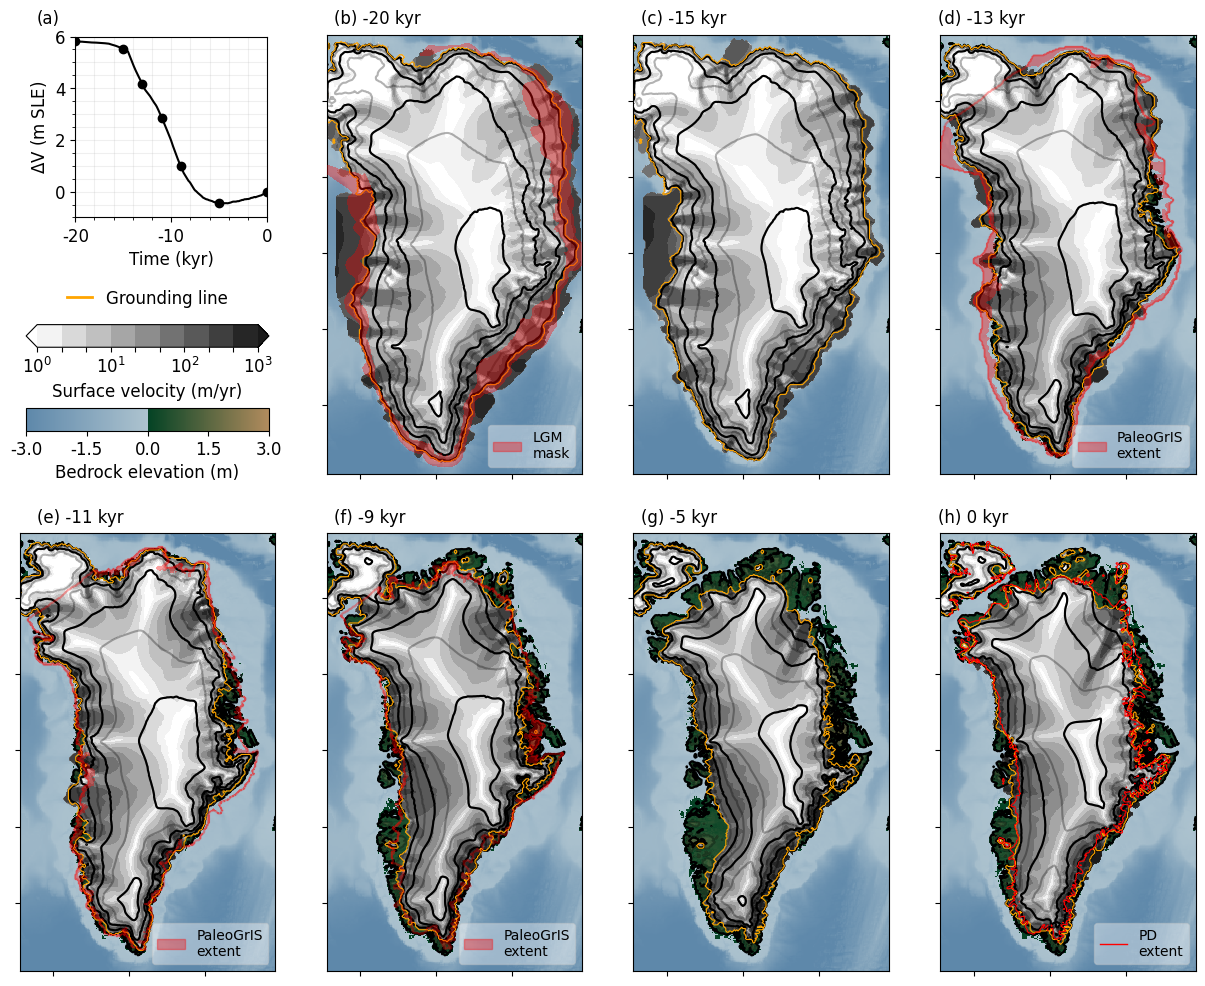

In [3]:
def pd_plot(ax,sim,uxy_s_map,zmap):
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    ice=xr.where((sim.f_grnd==1)&(sim.H_ice>0), 1, 0)
    log_uxy = sim.uxy_s.where(sim.H_ice>0) + 1e-8
    mask_gl = xr.where((sim.mask_bed<4)&(sim.mask_bed>1),1,0)

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')
    # ice = ax.contourf(xc, yc, ice, colors=['White'],levels=np.linspace(0.5, 1.2, 2))

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')
    cs3 = ax.contour(xc, yc, mask_gl, levels=np.linspace(0,1,1), colors='orange',linewidths=0.8)

    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return bat, vel

def put_legend(ax,rect):
    leg = ax.legend(handles=[rect], loc='lower right', frameon=True,fontsize=10)
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(0.4)  # Fondo semitran
    return 

colors = ["#ffffff", "#a8a8a8", "#000000"]

# Crear un colormap interpolado con 10 niveles
uxy_s_map = truncate_colormap(plt.get_cmap('gray_r'), minval=0, maxval=0.9)

zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
            (0.0, "#5E88AA"),
            (0.499, "#ADC3CF"),
            (0.50, "#024224"),
            (1.0, "#b18b5d")])

fig, axs=plt.subplots(2,4, figsize=(12,10))
times=[-20000,-15000,-13000,-11000,-9000,-5000,0]
red_patch = mpatches.Patch(color='red', alpha=0.35, label='PaleoGrIS\nextent')
for t in times:
    if t < times[3]: ax=axs[0,times.index(t)+1]
    else: ax=axs[1,times.index(t)-3]
    sim=best.sel(time=t)
    bed,vel=pd_plot(ax,sim,uxy_s_map,zmap)
    ax.set_xlim([best.xc.min(), best.xc.max()])
    ax.set_ylim([best.yc.min(), best.yc.max()])
    year=-t
    if year in np.unique(leger.age):
        iso_l = xr.where((leger.age <= year), 1, 0)
        iso_l2 = xr.where((leger.age == year), 1, 0)
        if year!=0:
            ax.contourf(iso_l2.xc,iso_l2.yc,iso_l2,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.35,zorder=5,linewidth=1)
            ax.contour(iso_l.xc,iso_l.yc,iso_l,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.35,zorder=5)
            put_legend(ax,red_patch)

        else:
            # ax.contour(iso_l.xc,iso_l.yc,iso_l,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.8,linewidths=0.5,zorder=5)
            ax.contour(obs.xc, obs.yc, obs.H_ice, levels=np.linspace(50,100,1), colors='red', linestyles='solid', linewidths=0.8,zorder=5)
            put_legend(ax,Line2D([0], [0], color='red', lw=1, alpha=1, label='PD\nextent'))

    

ax_try=axs[0,1]
mask = lgm.mask.where(lgm.mask==3)
im_lgm=ax_try.contourf(lgm.xc, lgm.yc, mask, colors='red',  alpha=0.35, linewidths=1.5,zorder=5)   
put_legend(ax_try,mpatches.Patch(color='red', alpha=0.35, label='LGM\nmask'))

        
# Leyenda
ax_leg=axs[0,0]
ax_leg.axis('off')

gl_line = Line2D([0], [0], color='orange', lw=2, label='Grounding line')
leg_gl = ax_leg.legend(handles=[gl_line], loc='lower center', 
                       bbox_to_anchor=(0.5, 0.35), # Ajusta el 0.4 para subir/bajar
                       frameon=False, 
                       handlelength=1.5)

axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
bbox_transform=ax_leg.transAxes,borderpad=3)
cb = plt.colorbar(bed, cax=axins, orientation='horizontal', ticks=[-3,-1.5,0,1.5,3],shrink=0.5)
cb.set_label('Bedrock elevation (m)')

axins = inset_axes( ax_leg, width="95%", height="5%", 
loc="lower center", bbox_transform=ax_leg.transAxes,borderpad=8)
cb = plt.colorbar(vel, cax=axins, orientation='horizontal',shrink=0.4)
cb.set_label('Surface velocity (m/yr)')

ax_vol = inset_axes(ax_leg, width="75%", height="40%", 
loc="upper right", bbox_transform=ax_leg.transAxes)

ax_vol.plot(best1.time*1e-3, best1.V_sle-best1.V_sle[-1], color='black')

for t in times:
    sim1=best1.sel(time=t)
    ax_vol.plot(sim1.time*1e-3, sim1.V_sle-best1.V_sle[-1], marker='o', color='black')

ax_vol.set_xlabel('Time (kyr)')
ax_vol.set_ylabel('$\Delta$V (m SLE)')
ax_vol.xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax_vol.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax_vol.grid(which="both",alpha=0.2)
ax_vol.set_xlim(-20,0)
ax_vol.set_ylim(-1,6)

h=6.5

ax_vol.text(-24,h,"(a)")
ax_vol.text(7,h,f"(b) {int(times[0]*1e-3)} kyr")
ax_vol.text(39,h,f"(c) {int(times[1]*1e-3)} kyr")
ax_vol.text(70,h,f"(d) {int(times[2]*1e-3)} kyr")
h=-12.8
ax_vol.text(-24,h,f"(e) {int(times[3]*1e-3)} kyr")
ax_vol.text(7,h,f"(f) {int(times[4]*1e-3)} kyr")
ax_vol.text(39,h,f"(g) {int(times[5]*1e-3)} kyr")
ax_vol.text(70,h,f"(h) {int(times[6]*1e-3)} kyr")

plt.subplots_adjust(
        left=0.01,   
        right=0.99, 
        top=0.95,    
        bottom=0,  
        wspace=0.2,  
        hspace=0.1)
plt.savefig(f"../figs_final/fig5_{n_best}_best_ice.png",dpi=300)
plt.close()


/tmp/ipykernel_1574300/906692049.py:67: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
/tmp/ipykernel_1574300/906692049.py:72: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%",
/tmp/ipykernel_1574300/906692049.py:77: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_vol = inset_axes(ax_leg, width="75%", height="40%",


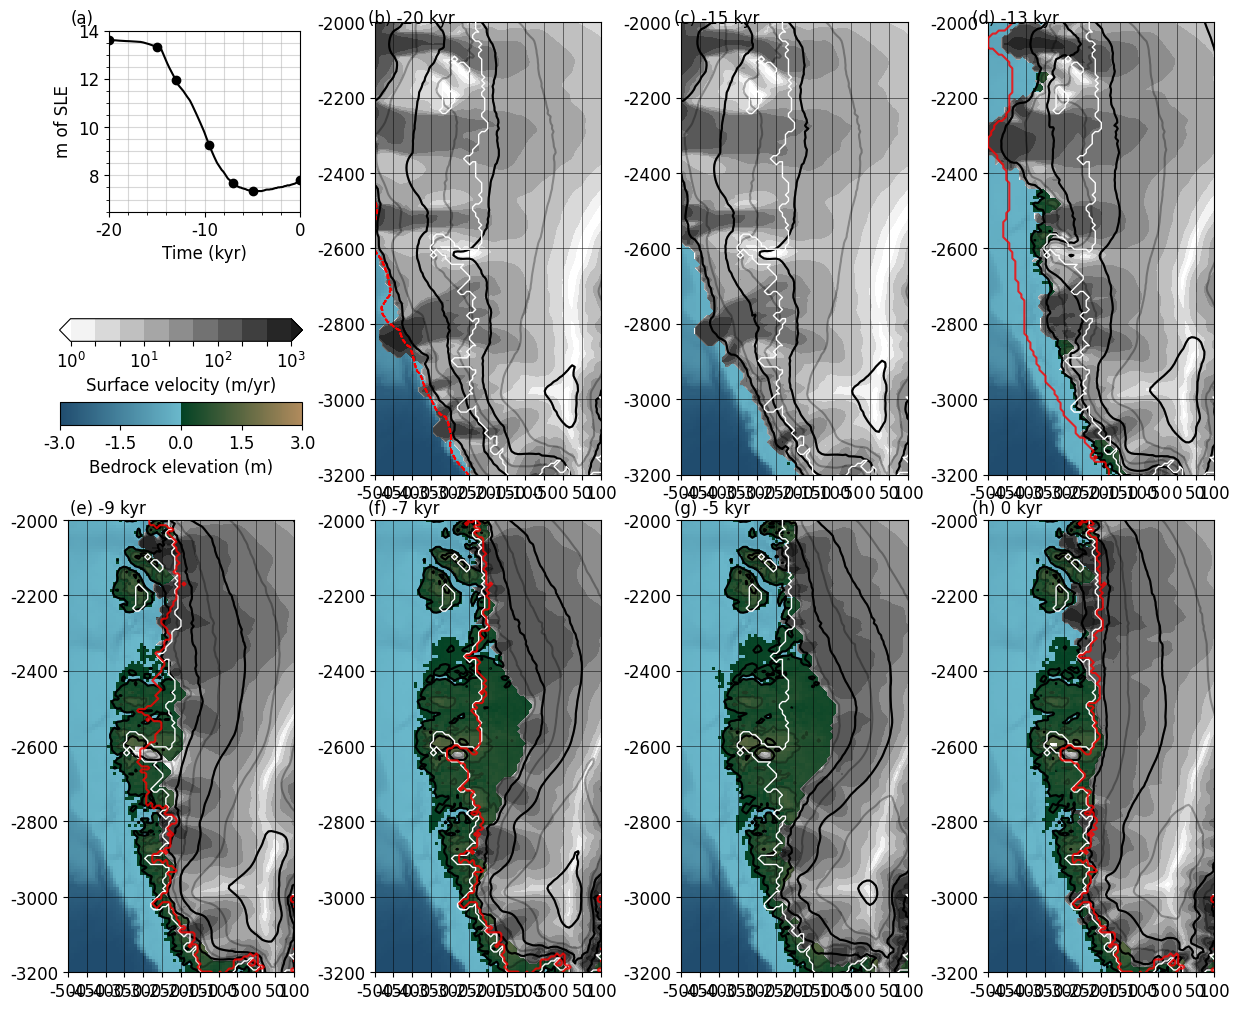

In [4]:
def pd_plot(ax,sim,uxy_s_map,zmap):
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    ice=xr.where((sim.f_grnd==1)&(sim.H_ice>0), 1, 0)
    log_uxy = sim.uxy_s.where(sim.H_ice>0) + 1e-8

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')
    # ice = ax.contourf(xc, yc, ice, colors=['White'],levels=np.linspace(0.5, 1.2, 2))

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')

    ax.set_aspect(1)
    ax.tick_params(labelbottom=True, labelleft=True)    

    return bat, vel

colors = ["#ffffff", "#a8a8a8", "#000000"]

import matplotlib.ticker as ticker
loc = ticker.MultipleLocator(base=50)
# Crear un colormap interpolado con 10 niveles
uxy_s_map = truncate_colormap(plt.get_cmap('gray_r'), minval=0, maxval=0.9)

zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
(0.0, "#204c6e"),
(0.499, "#6ab8cb"),
(0.50, "#024224"),
(1.0, "#b18b5d")])

fig, axs=plt.subplots(2,4, figsize=(12,10))
times=[-20000,-15000,-13000,-9500,-7000,-5000,0]

for t in times:
    if t < times[3]: ax=axs[0,times.index(t)+1]
    else: ax=axs[1,times.index(t)-3]
    sim=best.sel(time=t,method="nearest")
    bed,vel=pd_plot(ax,sim,uxy_s_map,zmap)
    # ax.set_xlim([best.xc.min(), best.xc.max()])
    # ax.set_ylim([best.yc.min(), best.yc.max()])
    ax.set_xlim([-500, 100])
    ax.set_ylim([-3200, -2000])
    year=-t
    ax.contour(obs.xc, obs.yc, obs.H_ice, levels=np.linspace(0,100,1), colors='white', linestyles='solid', linewidths=1,zorder=5)

    if year in np.unique(leger.age):
        iso_l = xr.where((leger.age <= year), 1, 0)
        ax.contour(iso_l.xc,iso_l.yc,iso_l,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.8,zorder=5)#levels=np.linspace(year-0.5, year+0.5, 2),colors=["red"], 
    ax.xaxis.set_major_locator(loc)
    # ax.yaxis.set_major_locator(loc)
    ax.grid(True, which='both', linestyle='solid', linewidth=0.5, color='black', alpha=0.7,zorder=10)
    ax.autoscale_view()


ax_try=axs[0,1]
im_lgm=ax_try.contour(lgm.xc, lgm.yc, lgm_leg, colors='red',  linestyles="dashed",linewidths=1)

        
# Leyenda
ax_leg=axs[0,0]
ax_leg.axis('off')
axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
bbox_transform=ax_leg.transAxes,borderpad=3)
cb = plt.colorbar(bed, cax=axins, orientation='horizontal', ticks=[-3,-1.5,0,1.5,3],shrink=0.5)
cb.set_label('Bedrock elevation (m)')

axins = inset_axes( ax_leg, width="95%", height="5%", 
loc="lower center", bbox_transform=ax_leg.transAxes,borderpad=8)
cb = plt.colorbar(vel, cax=axins, orientation='horizontal',shrink=0.4)
cb.set_label('Surface velocity (m/yr)')

ax_vol = inset_axes(ax_leg, width="75%", height="40%", 
loc="upper right", bbox_transform=ax_leg.transAxes)
1081
ax_vol.plot(best1.time*1e-3, best1.V_sle, color='black')

for t in times:
    sim1=best1.sel(time=t)
    ax_vol.plot(sim1.time*1e-3, sim1.V_sle, marker='o', color='black')

ax_vol.set_xlabel('Time (kyr)')
ax_vol.set_ylabel('m of SLE')
ax_vol.xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax_vol.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax_vol.grid(which="both",alpha=0.5)
ax_vol.set_xlim(-20,0)
ax_vol.set_ylim(6.5,14)

h=14.3

ax_vol.text(-24,h,"(a)")
ax_vol.text(7,h,f"(b) {int(times[0]*1e-3)} kyr")
ax_vol.text(39,h,f"(c) {int(times[1]*1e-3)} kyr")
ax_vol.text(70,h,f"(d) {int(times[2]*1e-3)} kyr")
h=-6
ax_vol.text(-24,h,f"(e) {int(times[3]*1e-3)} kyr")
ax_vol.text(7,h,f"(f) {int(times[4]*1e-3)} kyr")
ax_vol.text(39,h,f"(g) {int(times[5]*1e-3)} kyr")
ax_vol.text(70,h,f"(h) {int(times[6]*1e-3)} kyr")

plt.subplots_adjust(
        left=0.01,   
        right=0.99, 
        top=0.95,    
        bottom=0,  
        wspace=0.2,  
        hspace=0.1)
# plt.savefig(f"../figs/{n_best}_best_ice.png",dpi=300)
# plt.close()


/tmp/ipykernel_2819594/115567578.py:67: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
/tmp/ipykernel_2819594/115567578.py:72: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax_leg, width="95%", height="5%",
/tmp/ipykernel_2819594/115567578.py:77: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_vol = inset_axes(ax_leg, width="75%", height="40%",


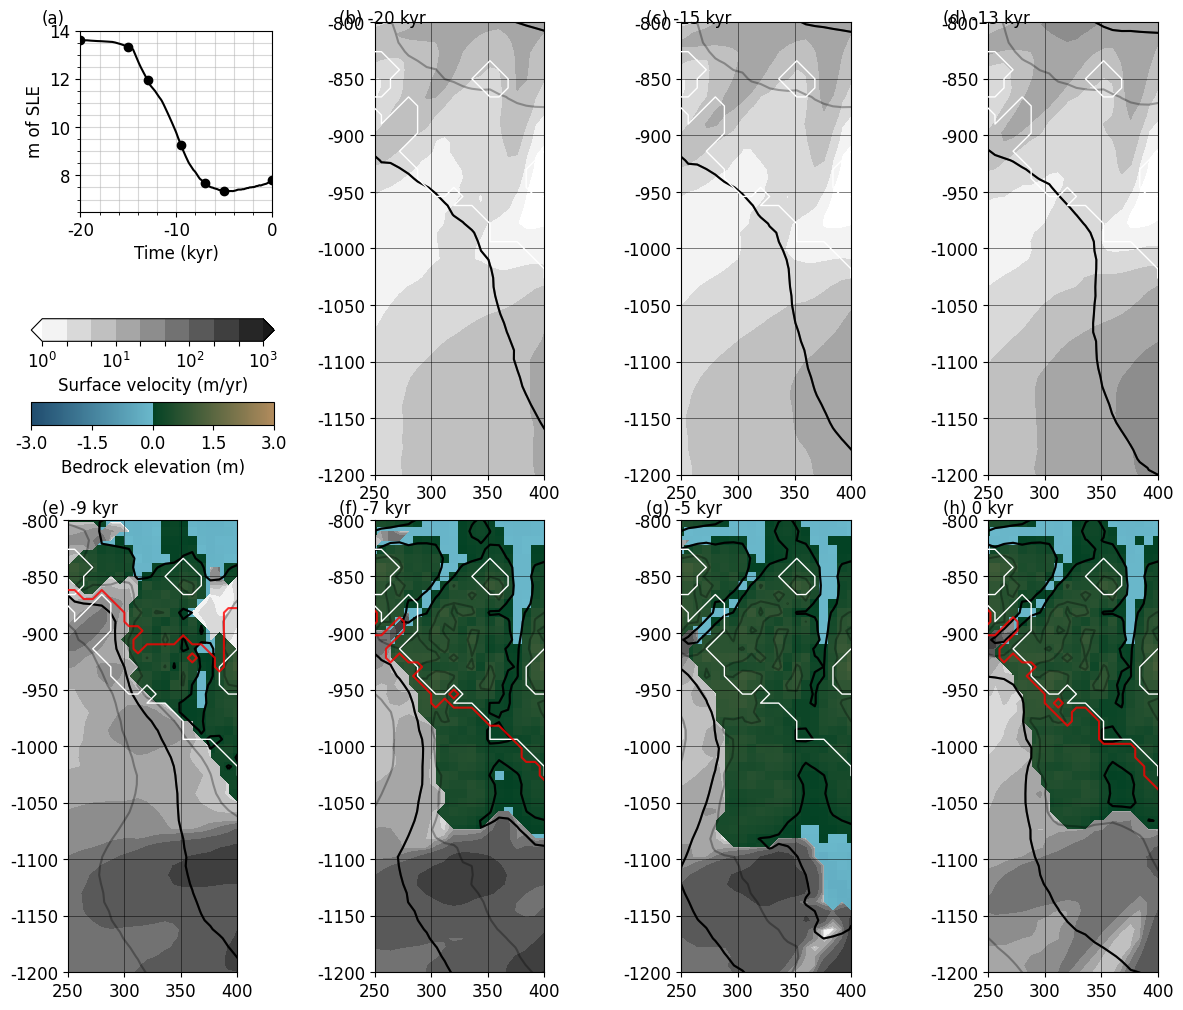

In [8]:
def pd_plot(ax,sim,uxy_s_map,zmap):
    xc=sim.xc
    yc=sim.yc
    z_bed=sim.z_bed*1e-3
    z_srf=sim.z_bed+sim.H_ice
    ice=xr.where((sim.f_grnd==1)&(sim.H_ice>0), 1, 0)
    log_uxy = sim.uxy_s.where(sim.H_ice>0) + 1e-8

    # Dibujar mapas
    bat = ax.pcolormesh(xc, yc, z_bed, cmap=zmap, vmin=-3, vmax=3)
    vel = ax.contourf(xc, yc, log_uxy, levels = np.logspace(0,3,10) ,  norm = LogNorm(), cmap = uxy_s_map,extend='both')
    # ice = ax.contourf(xc, yc, ice, colors=['White'],levels=np.linspace(0.5, 1.2, 2))

    # # Contornos
    cs1 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 3600, 500), colors='black', alpha=0.3)
    cs2 = ax.contour(xc, yc, z_srf, levels=np.arange(150, 4150, 1000), colors='black')

    ax.set_aspect(1)
    ax.tick_params(labelbottom=True, labelleft=True)    

    return bat, vel

colors = ["#ffffff", "#a8a8a8", "#000000"]

import matplotlib.ticker as ticker
loc = ticker.MultipleLocator(base=50)
# Crear un colormap interpolado con 10 niveles
uxy_s_map = truncate_colormap(plt.get_cmap('gray_r'), minval=0, maxval=0.9)

zmap = mcolors.LinearSegmentedColormap.from_list("zmap", [
(0.0, "#204c6e"),
(0.499, "#6ab8cb"),
(0.50, "#024224"),
(1.0, "#b18b5d")])

fig, axs=plt.subplots(2,4, figsize=(12,10))
times=[-20000,-15000,-13000,-9500,-7000,-5000,0]

for t in times:
    if t < times[3]: ax=axs[0,times.index(t)+1]
    else: ax=axs[1,times.index(t)-3]
    sim=best.sel(time=t,method="nearest")
    bed,vel=pd_plot(ax,sim,uxy_s_map,zmap)
    # ax.set_xlim([best.xc.min(), best.xc.max()])
    # ax.set_ylim([best.yc.min(), best.yc.max()])
    ax.set_xlim([250, 400])
    ax.set_ylim([-1200, -800])
    year=-t
    ax.contour(obs.xc, obs.yc, obs.H_ice, levels=np.linspace(0,100,1), colors='white', linestyles='solid', linewidths=1,zorder=5)

    if year in np.unique(leger.age):
        iso_l = xr.where((leger.age <= year), 1, 0)
        ax.contour(iso_l.xc,iso_l.yc,iso_l,colors='red',levels=np.linspace(0.5, 1.2, 2),alpha=0.8,zorder=5)#levels=np.linspace(year-0.5, year+0.5, 2),colors=["red"], 
    ax.xaxis.set_major_locator(loc)
    # ax.yaxis.set_major_locator(loc)
    ax.grid(True, which='both', linestyle='solid', linewidth=0.5, color='black', alpha=0.7,zorder=10)
    ax.autoscale_view()


ax_try=axs[0,1]
im_lgm=ax_try.contour(lgm.xc, lgm.yc, lgm_leg, colors='red',  linestyles="dashed",linewidths=1)

        
# Leyenda
ax_leg=axs[0,0]
ax_leg.axis('off')
axins = inset_axes( ax_leg, width="95%", height="5%", loc="lower center",
bbox_transform=ax_leg.transAxes,borderpad=3)
cb = plt.colorbar(bed, cax=axins, orientation='horizontal', ticks=[-3,-1.5,0,1.5,3],shrink=0.5)
cb.set_label('Bedrock elevation (m)')

axins = inset_axes( ax_leg, width="95%", height="5%", 
loc="lower center", bbox_transform=ax_leg.transAxes,borderpad=8)
cb = plt.colorbar(vel, cax=axins, orientation='horizontal',shrink=0.4)
cb.set_label('Surface velocity (m/yr)')

ax_vol = inset_axes(ax_leg, width="75%", height="40%", 
loc="upper right", bbox_transform=ax_leg.transAxes)
1081
ax_vol.plot(best1.time*1e-3, best1.V_sle, color='black')

for t in times:
    sim1=best1.sel(time=t)
    ax_vol.plot(sim1.time*1e-3, sim1.V_sle, marker='o', color='black')

ax_vol.set_xlabel('Time (kyr)')
ax_vol.set_ylabel('m of SLE')
ax_vol.xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax_vol.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax_vol.grid(which="both",alpha=0.5)
ax_vol.set_xlim(-20,0)
ax_vol.set_ylim(6.5,14)

h=14.3

ax_vol.text(-24,h,"(a)")
ax_vol.text(7,h,f"(b) {int(times[0]*1e-3)} kyr")
ax_vol.text(39,h,f"(c) {int(times[1]*1e-3)} kyr")
ax_vol.text(70,h,f"(d) {int(times[2]*1e-3)} kyr")
h=-6
ax_vol.text(-24,h,f"(e) {int(times[3]*1e-3)} kyr")
ax_vol.text(7,h,f"(f) {int(times[4]*1e-3)} kyr")
ax_vol.text(39,h,f"(g) {int(times[5]*1e-3)} kyr")
ax_vol.text(70,h,f"(h) {int(times[6]*1e-3)} kyr")

plt.subplots_adjust(
        left=0.01,   
        right=0.99, 
        top=0.95,    
        bottom=0,  
        wspace=0.2,  
        hspace=0.1)
# plt.savefig(f"../figs/{n_best}_best_ice.png",dpi=300)
# plt.close()


In [32]:

cmb=best2.calv.mean(axis=1).mean(axis=1)

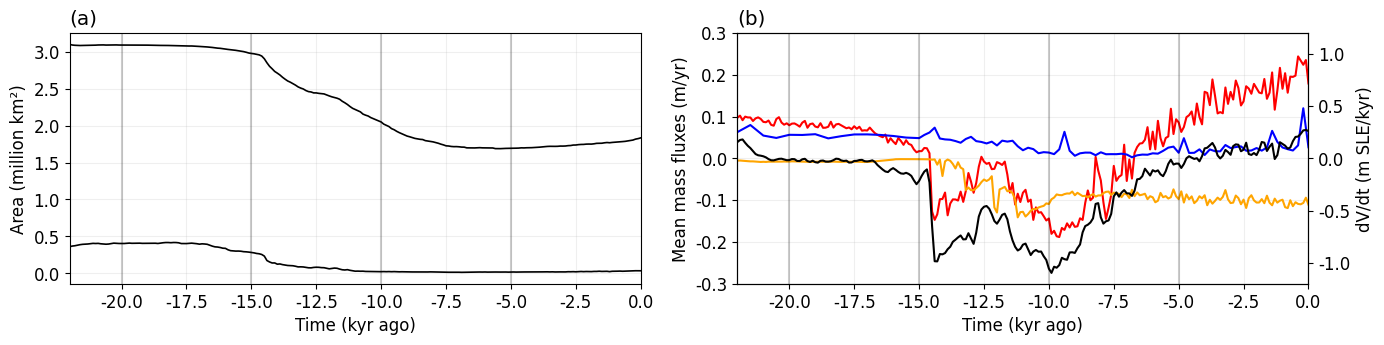

In [44]:
time = best1.time*1e-3
time2=best2.time*1e-3
fig, axs = plt.subplots(1,2,figsize=(14,4))

A_obs=1.7
V_obs=7.4

axs[0].plot(time,best1.A_ice_g, color='black', linewidth=1.2,zorder=2)
axs[0].plot(time,best1.A_ice_f, color='black', linewidth=1.2,zorder=2)

# present=axs[0].axhline(y=A_obs, color='#64A8CD', linestyle='-', alpha=0.8,linewidth=2,zorder=2)

# paleogris = axs[0].errorbar(-leger["time"][1:] * 1e-3,leger.tot[1:],xerr=leger.time_err[1:]*1e-3,fmt='o',ecolor='black',
#                 markersize=5,markerfacecolor='red',markeredgecolor='black',markeredgewidth=0.8,
#                 capsize=2,zorder=4,label="Leger et al. (2024)")

dvdt=np.gradient(best1.V_sle, best1.time*1e-3)
axs[1].plot(time,best1.smb,color="red",label="smb")
axs[1].plot(time,best1.bmb,color="orange",label="bmb")
axs[1].plot(time2,cmb,color="blue",label="calving")
ax_doble=axs[1].twinx()
ax_doble.plot(time,dvdt,color="black",label="calving")
ax_doble.set_ylabel('dV/dt (m SLE/kyr)')
ax_doble.set_ylim(-1.2,1.2)
axs[1].set_ylim(-0.3,0.3)
axs[0].set_ylabel('Area (million km²)')
axs[1].set_ylabel('Mean mass fluxes (m/yr)')




for ax in axs:
    ax.set_xlabel('Time (kyr ago)')
    ax.grid(alpha=0.2,zorder=2)
    ax.axvline(x=-20, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-15, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-10, color='black', linestyle='-', alpha=0.2)
    ax.axvline(x=-5, color='black', linestyle='-', alpha=0.2)
    ax.set_xlim(-22,0)

axs[0].set_title('(a)',loc='left')
axs[1].set_title('(b)',loc='left')
plt.tight_layout()
plt.subplots_adjust(top=0.8)


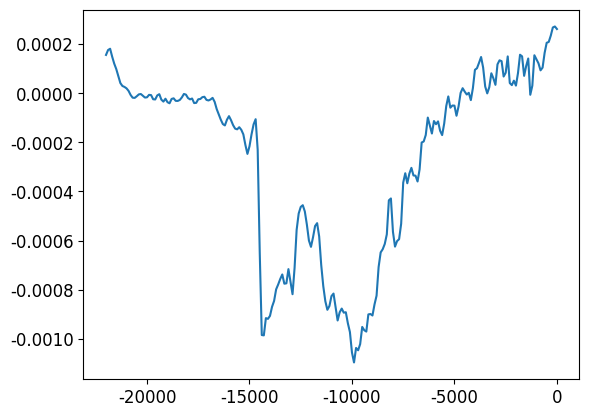

In [39]:
dvdt=np.gradient(best1.V_sle, best1.time)
plt.plot(best1.time,dvdt)